# 🛡️ Detection of Unwanted / Junk / Phishing / Fraudulent Messages
## Using Machine Learning — Multilingual (English + Hindi + Hinglish)
### B.Tech CSE Final Year Research Project
---
**Features:**
- English, Hindi & Hinglish message classification
- NLP Preprocessing with multilingual support
- Models: Logistic Regression, SVM, Naive Bayes, Random Forest
- mBERT-based multilingual classification (Advanced)
- TF-IDF + Character n-gram features
- Full evaluation: Accuracy, Precision, Recall, F1, ROC-AUC


In [1]:
# ─────────────────────────────────────────
# CELL 2: Install Required Libraries
# ─────────────────────────────────────────
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn
!pip install wordcloud langdetect indicnlp
!pip install sentence-transformers
print('✅ All libraries installed!')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=ed517d83ce09412473fdb193a30c2c240ae2f923386f0480af30e1f472715fb6
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect
✅ All libraries installed!


In [2]:
# ─────────────────────────────────────────
# CELL 3: Import Libraries
# ─────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import nltk
import re
import string
import warnings
import pickle
from collections import Counter

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, roc_auc_score, classification_report,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline

# NLP
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

# Language detection
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print('✅ All imports successful!')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


✅ All imports successful!


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## 📋 CSV Format for Hindi & Hinglish Datasets

Your `hindi_data.csv` and `hinglish_data.csv` must have **exactly 2 columns**:

| text | label |
|------|-------|
| आपने 10 लाख की लॉटरी जीती है! | spam |
| कल मिलते हैं, ठीक है? | ham |
| Bhai free iPhone jeetne ke liye click kar | spam |
| Office mein late ho raha hoon | ham |

**Minimum required:** 3000 messages per file (mix of spam and ham).  
**Recommended ratio:** ~70% ham, ~30% spam (realistic distribution).  
**Encoding:** Save as UTF-8 (important for Devanagari script in Hindi).  

### How to create the CSV in Excel / Google Sheets:
1. Column A header → `text`
2. Column B header → `label`
3. Fill rows with your messages and `spam` / `ham` labels
4. File → Download as CSV (UTF-8)
5. Name it exactly: `hindi_data.csv` or `hinglish_data.csv`


In [3]:
# ─────────────────────────────────────────
# CELL 4: Upload Dataset CSV Files
# Upload all three files when prompted:
#   1. spam.csv        → English dataset (Kaggle SMS Spam Collection)
#   2. hindi_data.csv  → Your custom Hindi dataset
#   3. hinglish_data.csv → Your custom Hinglish dataset
#
# CSV format required (same for all three files):
#   Column 1: text   → the message text
#   Column 2: label  → 'spam' or 'ham'
# ─────────────────────────────────────────

from google.colab import files
import io

print('📂 Please upload your CSV files when the dialog opens...')
print('   Required files:')
print('   1. spam.csv          (English - Kaggle dataset)')
print('   2. hindi_data.csv    (Hindi - your custom dataset, min 3000 rows)')
print('   3. hinglish_data.csv (Hinglish - your custom dataset, min 3000 rows)')
print()

uploaded = files.upload()

print(f'\n✅ Uploaded files: {list(uploaded.keys())}')


📂 Please upload your CSV files when the dialog opens...
   Required files:
   1. spam.csv          (English - Kaggle dataset)
   2. hindi_data.csv    (Hindi - your custom dataset, min 3000 rows)
   3. hinglish_data.csv (Hinglish - your custom dataset, min 3000 rows)



Saving hindi_data.csv to hindi_data.csv
Saving hinglish_data.csv to hinglish_data.csv
Saving spam.csv to spam.csv

✅ Uploaded files: ['hindi_data.csv', 'hinglish_data.csv', 'spam.csv']


In [4]:
# ─────────────────────────────────────────
# CELL 5: Load All Three Datasets from Uploaded CSVs
# ─────────────────────────────────────────

import pandas as pd
import io

# ── Load English Dataset (spam.csv - Kaggle format) ──
if 'spam.csv' in uploaded:
    df_eng = pd.read_csv(io.BytesIO(uploaded['spam.csv']), encoding='latin1')
    # Kaggle spam.csv has columns v1, v2 (and unnamed extras)
    if 'v1' in df_eng.columns and 'v2' in df_eng.columns:
        df_eng = df_eng[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
    elif 'label' in df_eng.columns and 'text' in df_eng.columns:
        df_eng = df_eng[['text', 'label']]
    df_eng['language'] = 'english'
    df_eng = df_eng[['text', 'label', 'language']].drop_duplicates()
    print(f'✅ English dataset loaded: {df_eng.shape[0]} messages')
    print(df_eng['label'].value_counts().to_string())
else:
    print('⚠️  spam.csv not found in uploads! Please re-run Cell 4 and upload it.')
    df_eng = pd.DataFrame(columns=['text', 'label', 'language'])

print()

# ── Load Hindi Dataset ──
if 'hindi_data.csv' in uploaded:
    df_hindi = pd.read_csv(io.BytesIO(uploaded['hindi_data.csv']), encoding='utf-8')
    # Normalise column names (accept text/Text/message, label/Label/category)
    df_hindi.columns = [c.strip().lower() for c in df_hindi.columns]
    col_map = {}
    for c in df_hindi.columns:
        if c in ['text', 'message', 'msg', 'sms']:   col_map[c] = 'text'
        if c in ['label', 'category', 'class', 'type']: col_map[c] = 'label'
    df_hindi = df_hindi.rename(columns=col_map)[['text', 'label']]
    df_hindi['label'] = df_hindi['label'].str.strip().str.lower()
    df_hindi['language'] = 'hindi'
    df_hindi = df_hindi.drop_duplicates()
    print(f'✅ Hindi dataset loaded: {df_hindi.shape[0]} messages')
    print(df_hindi['label'].value_counts().to_string())
else:
    print('⚠️  hindi_data.csv not found! Please re-run Cell 4 and upload it.')
    df_hindi = pd.DataFrame(columns=['text', 'label', 'language'])

print()

# ── Load Hinglish Dataset ──
if 'hinglish_data.csv' in uploaded:
    df_hinglish = pd.read_csv(io.BytesIO(uploaded['hinglish_data.csv']), encoding='utf-8')
    df_hinglish.columns = [c.strip().lower() for c in df_hinglish.columns]
    col_map = {}
    for c in df_hinglish.columns:
        if c in ['text', 'message', 'msg', 'sms']:      col_map[c] = 'text'
        if c in ['label', 'category', 'class', 'type']: col_map[c] = 'label'
    df_hinglish = df_hinglish.rename(columns=col_map)[['text', 'label']]
    df_hinglish['label'] = df_hinglish['label'].str.strip().str.lower()
    df_hinglish['language'] = 'hinglish'
    df_hinglish = df_hinglish.drop_duplicates()
    print(f'✅ Hinglish dataset loaded: {df_hinglish.shape[0]} messages')
    print(df_hinglish['label'].value_counts().to_string())
else:
    print('⚠️  hinglish_data.csv not found! Please re-run Cell 4 and upload it.')
    df_hinglish = pd.DataFrame(columns=['text', 'label', 'language'])

print()
print('=== Dataset Summary ===')
print(f'English  : {len(df_eng):>5} messages')
print(f'Hindi    : {len(df_hindi):>5} messages')
print(f'Hinglish : {len(df_hinglish):>5} messages')
print(f'Total    : {len(df_eng)+len(df_hindi)+len(df_hinglish):>5} messages')


✅ English dataset loaded: 5169 messages
label
ham     4516
spam     653

✅ Hindi dataset loaded: 100 messages
label
ham     50
spam    50

✅ Hinglish dataset loaded: 100 messages
label
ham     50
spam    50

=== Dataset Summary ===
English  :  5169 messages
Hindi    :   100 messages
Hinglish :   100 messages
Total    :  5369 messages


In [5]:
# ─────────────────────────────────────────
# CELL 6: Merge All Three Datasets
# ─────────────────────────────────────────

from sklearn.preprocessing import LabelEncoder

df = pd.concat([df_eng, df_hindi, df_hinglish], ignore_index=True)
df = df.drop_duplicates(subset='text').reset_index(drop=True)

# Ensure labels are lowercase
df['label'] = df['label'].str.strip().str.lower()

encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['label'])  # ham=0, spam=1

print('=== Merged Dataset Info ===')
print(f'Total messages : {len(df)}')
print(f'Languages      : {df["language"].value_counts().to_dict()}')
print(f'Class balance  : {df["label"].value_counts().to_dict()}')
print()
df.info()
print()
df.head(10)


=== Merged Dataset Info ===
Total messages : 5369
Languages      : {'english': 5169, 'hindi': 100, 'hinglish': 100}
Class balance  : {'ham': 4616, 'spam': 753}

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5369 entries, 0 to 5368
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      5369 non-null   object
 1   label     5369 non-null   object
 2   language  5369 non-null   object
 3   target    5369 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 167.9+ KB



,text,label,language,target
0,"Go until jurong point, crazy.. Available only ...",ham,english,0
1,Ok lar... Joking wif u oni...,ham,english,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,english,1
3,U dun say so early hor... U c already then say...,ham,english,0
4,"Nah I don't think he goes to usf, he lives aro...",ham,english,0
5,FreeMsg Hey there darling it's been 3 week's n...,spam,english,1
6,Even my brother is not like to speak with me. ...,ham,english,0
7,As per your request 'Melle Melle (Oru Minnamin...,ham,english,0
8,WINNER!! As a valued network customer you have...,spam,english,1
9,Had your mobile 11 months or more? U R entitle...,spam,english,1


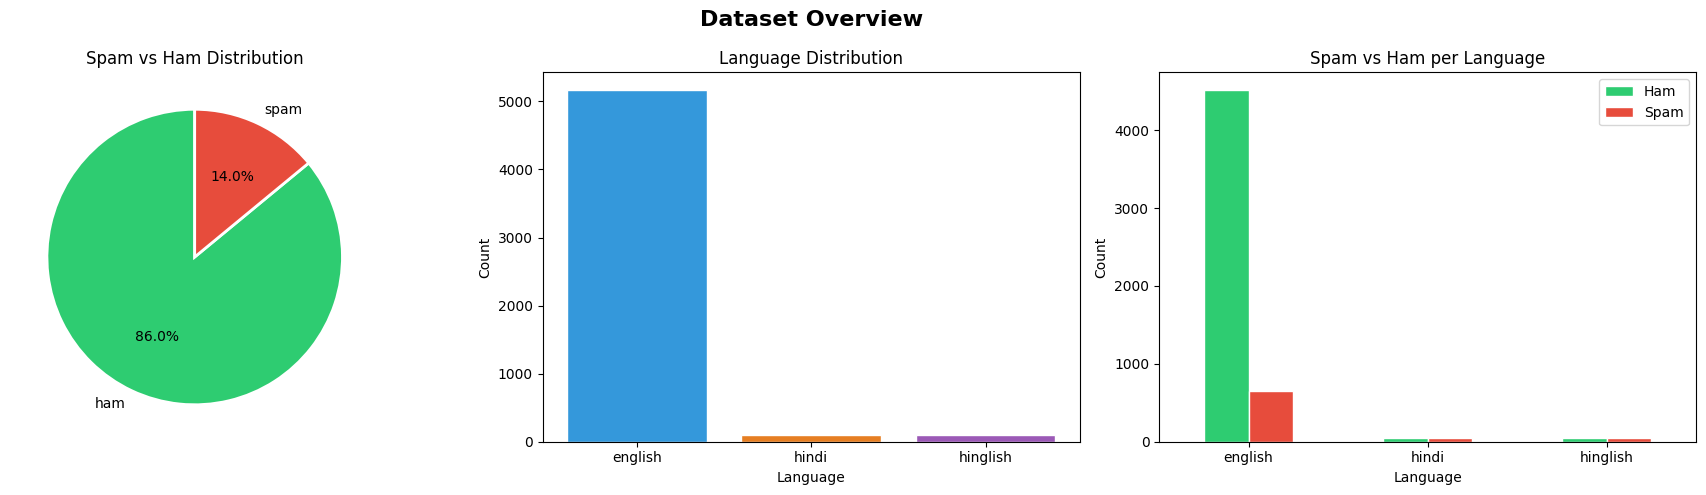


=== Message Length Statistics ===
      num_chars                                                  num_words  \
          count    mean    std   min    25%    50%    75%    max     count   
label                                                                        
ham      4616.0   69.71  55.98   2.0   34.0   51.0   89.0  910.0    4616.0   
spam      753.0  127.11  39.38  13.0  107.0  145.0  156.0  224.0     753.0   

                                                   
        mean    std  min   25%   50%   75%    max  
label                                              
ham    13.98  11.04  1.0   7.0  10.0  18.0  171.0  
spam   21.92   7.17  2.0  17.0  24.0  27.0   35.0  


In [6]:
# ─────────────────────────────────────────
# CELL 7: Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold')

# 1. Spam vs Ham
counts = df['label'].value_counts()
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Spam vs Ham Distribution')

# 2. Language distribution
lang_counts = df['language'].value_counts()
axes[1].bar(lang_counts.index, lang_counts.values,
            color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='white')
axes[1].set_title('Language Distribution')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Count')

# 3. Spam/Ham per language
lang_label = df.groupby(['language', 'label']).size().unstack(fill_value=0)
lang_label.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', rot=0)
axes[2].set_title('Spam vs Ham per Language')
axes[2].set_xlabel('Language')
axes[2].set_ylabel('Count')
axes[2].legend(['Ham', 'Spam'])

plt.tight_layout()
plt.show()

# Message length analysis
df['num_chars']    = df['text'].apply(len)
df['num_words']    = df['text'].apply(lambda x: len(str(x).split()))

print('\n=== Message Length Statistics ===')
print(df.groupby('label')[['num_chars', 'num_words']].describe().round(2))


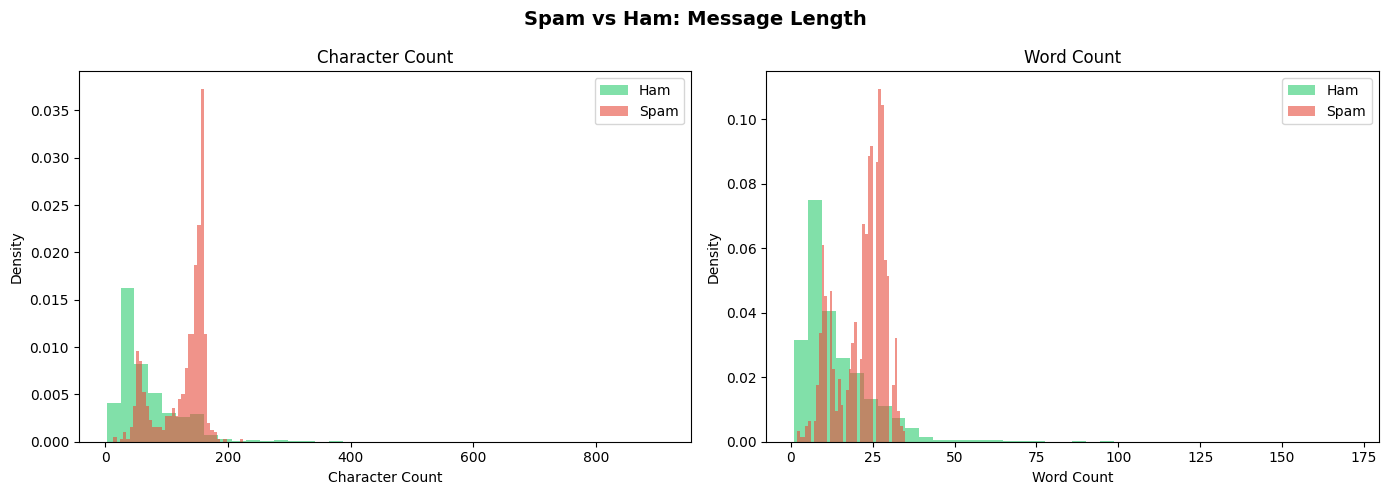

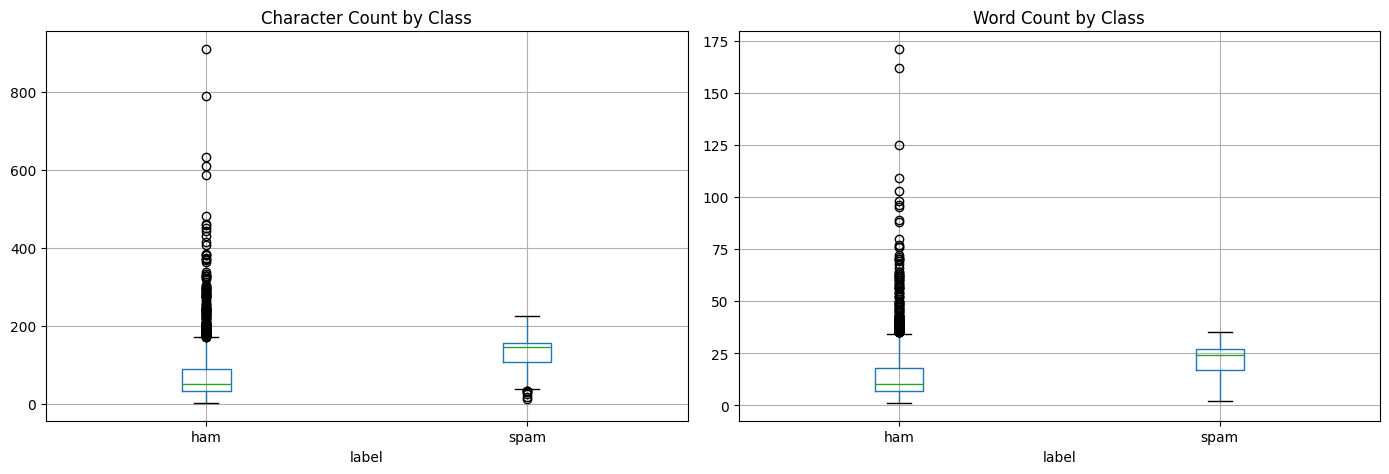

In [7]:
# ─────────────────────────────────────────
# CELL 8: Message Length Distribution
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Spam vs Ham: Message Length', fontsize=14, fontweight='bold')

for ax, col, title in zip(axes,
                          ['num_chars', 'num_words'],
                          ['Character Count', 'Word Count']):
    ax.hist(df[df['target']==0][col], bins=40, alpha=0.6,
            color='#2ecc71', label='Ham', density=True)
    ax.hist(df[df['target']==1][col], bins=40, alpha=0.6,
            color='#e74c3c', label='Spam', density=True)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

# Box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='num_chars', by='label', ax=axes[0])
axes[0].set_title('Character Count by Class')
df.boxplot(column='num_words', by='label', ax=axes[1])
axes[1].set_title('Word Count by Class')
plt.suptitle('')
plt.tight_layout()
plt.show()


In [8]:
# ─────────────────────────────────────────
# CELL 9: Language Detection Utility
# (Validates our manual language labels)
# ─────────────────────────────────────────

def detect_language(text):
    try:
        lang = detect(str(text))
        # Map langdetect codes to our labels
        if lang == 'hi':    return 'hindi'
        elif lang == 'en':  return 'english'
        else:               return 'hinglish'  # mixed / undetected = hinglish
    except:
        return 'unknown'

# Sample check on 20 rows
sample = df.sample(20, random_state=42)[['text', 'language']].copy()
sample['detected'] = sample['text'].apply(detect_language)
sample['match'] = sample['language'] == sample['detected']
print('Language detection sample check:')
print(sample[['text', 'language', 'detected', 'match']].to_string())
print(f'\nDetection accuracy on sample: {sample["match"].mean():.1%}')


Language detection sample check:
                                                                                                                                                                                       text  language  detected  match
410                                                                             FREE entry into our å£250 weekly competition just text the word WIN to 80086 NOW. 18 T&C www.txttowin.co.uk   english   english   True
3625                                   oh ya... Got hip hop open. Haha i was thinking can go for jazz then zoom to cine... Actually tonight i'm free leh... And there's a kb lesson tonight   english   english   True
838                                                Hai ana tomarrow am coming on morning.  &lt;DECIMAL&gt;  ill be there in sathy then we ll go to RTO office. Reply me after came to home.   english   english   True
4080                                                                                         Don't Think Ab

In [9]:
# ─────────────────────────────────────────
# CELL 10: Multilingual Text Preprocessing
# ─────────────────────────────────────────

ps = PorterStemmer()

# Extended stopwords: English + common Hinglish fillers
english_stops = set(stopwords.words('english'))
hinglish_stops = {
    'hai', 'hain', 'ho', 'tha', 'thi', 'the', 'ka', 'ki', 'ke',
    'ko', 'se', 'me', 'mein', 'pe', 'par', 'aur', 'ya', 'bhi',
    'yeh', 'ye', 'woh', 'wo', 'ek', 'koi', 'kuch', 'sab', 'apna',
    'apni', 'apne', 'uska', 'uski', 'uske', 'mera', 'meri', 'mere',
    'tera', 'teri', 'tere', 'humara', 'tumhara', 'unka', 'kya', 'kyun',
    'kaise', 'kab', 'kahan', 'kaun', 'nahi', 'nahin', 'mat', 'na',
    'ji', 'bhai', 'yaar', 'dost', 'sir', 'madam',
}
all_stops = english_stops | hinglish_stops

def preprocess_multilingual(text):
    """Preprocess English, Hindi, and Hinglish messages."""
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' url ', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' email ', text)
    # Normalize phone numbers
    text = re.sub(r'\b\d{10,}\b', ' phonenumber ', text)
    # Normalize currency / amounts
    text = re.sub(r'₹|rs\.?|inr', ' rupees ', text)
    text = re.sub(r'£|\$|€', ' currency ', text)
    # Keep Devanagari, Latin alphanumeric, spaces
    text = re.sub(r'[^\w\s\u0900-\u097F]', ' ', text)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize (simple split – works for both scripts)
    tokens = text.split()

    # Remove stopwords & single chars; stem Latin tokens
    cleaned = []
    for tok in tokens:
        if tok in all_stops or len(tok) < 2:
            continue
        # Stem only purely Latin tokens (English / Hinglish)
        if re.match(r'^[a-z]+$', tok):
            tok = ps.stem(tok)
        cleaned.append(tok)

    return ' '.join(cleaned)

# Apply
df['processed_text'] = df['text'].apply(preprocess_multilingual)

print('✅ Preprocessing complete!')
print('\nSample results:')
for _, row in df.sample(5, random_state=1).iterrows():
    print(f'[{row.language:8s}] [{row.label}] Original : {row.text[:70]}')
    print(f'           Processed: {row.processed_text[:70]}\n')


✅ Preprocessing complete!

Sample results:
[english ] [ham] Original : No..few hours before.went to hair cut .
           Processed: hou rupe went hair cut

[english ] [ham] Original : K.k:)apo k.good movie.
           Processed: apo good movi

[english ] [ham] Original : Then we wait 4 u lor... No need 2 feel bad lar...
           Processed: wait lor need feel bad lar

[english ] [ham] Original : Hi there. We have now moved in2 our pub . Would be great 2 c u if u cu
           Processed: hi move in2 pub would great cud come

[english ] [ham] Original : FR'NDSHIP is like a needle of a clock. Though V r in d same clock, V r
           Processed: fr ndship like needl clock though clock nt abl met evn meet itz 4few s



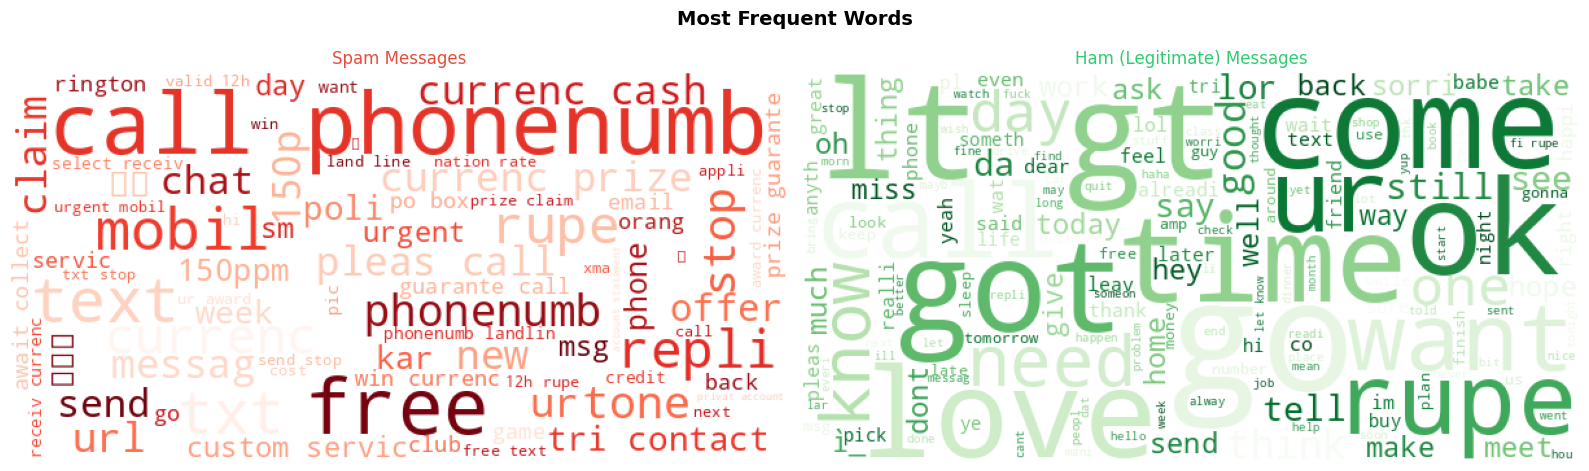

In [10]:
# ─────────────────────────────────────────
# CELL 11: WordCloud Visualization
# Shows most frequent words per label AND per language
# ─────────────────────────────────────────

from wordcloud import WordCloud

# ── Section 1: Overall Spam vs Ham WordCloud ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Overall — Most Frequent Words', fontsize=14, fontweight='bold')

spam_text = ' '.join(df[df['target']==1]['processed_text'].tolist())
ham_text  = ' '.join(df[df['target']==0]['processed_text'].tolist())

wc_spam = WordCloud(width=700, height=350, background_color='white',
                    min_font_size=8, colormap='Reds')
wc_ham  = WordCloud(width=700, height=350, background_color='white',
                    min_font_size=8, colormap='Greens')

if spam_text.strip():
    axes[0].imshow(wc_spam.generate(spam_text))
axes[0].axis('off')
axes[0].set_title('Spam Messages (All Languages)', color='#e74c3c',
                  fontsize=13, fontweight='bold')

if ham_text.strip():
    axes[1].imshow(wc_ham.generate(ham_text))
axes[1].axis('off')
axes[1].set_title('Ham Messages (All Languages)', color='#2ecc71',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Section 2: Per-Language WordClouds (Spam + Ham each) ─────────────────
lang_configs = [
    ('english',  'Reds',    'Greens',  '#3498db'),
    ('hindi',    'OrRd',    'YlGn',    '#e67e22'),
    ('hinglish', 'PuRd',    'BuGn',    '#9b59b6'),
]

for lang, cmap_spam, cmap_ham, title_color in lang_configs:
    lang_df_sub = df[df['language'] == lang]
    if len(lang_df_sub) == 0:
        print(f'⚠️  No data for {lang}, skipping WordCloud.')
        continue

    lang_spam = ' '.join(lang_df_sub[lang_df_sub['target']==1]['processed_text'].tolist())
    lang_ham  = ' '.join(lang_df_sub[lang_df_sub['target']==0]['processed_text'].tolist())

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    fig.suptitle(f'{lang.capitalize()} Messages — WordCloud',
                 fontsize=13, fontweight='bold', color=title_color)

    wc_s = WordCloud(width=700, height=320, background_color='white',
                     min_font_size=7, colormap=cmap_spam)
    wc_h = WordCloud(width=700, height=320, background_color='white',
                     min_font_size=7, colormap=cmap_ham)

    if lang_spam.strip():
        axes[0].imshow(wc_s.generate(lang_spam))
    else:
        axes[0].text(0.5, 0.5, 'No spam data', ha='center', va='center',
                     transform=axes[0].transAxes, fontsize=12)
    axes[0].axis('off')
    axes[0].set_title(f'Spam ({lang.capitalize()})', color='#e74c3c',
                      fontsize=11, fontweight='bold')

    if lang_ham.strip():
        axes[1].imshow(wc_h.generate(lang_ham))
    else:
        axes[1].text(0.5, 0.5, 'No ham data', ha='center', va='center',
                     transform=axes[1].transAxes, fontsize=12)
    axes[1].axis('off')
    axes[1].set_title(f'Ham ({lang.capitalize()})', color='#2ecc71',
                      fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
    print(f'  {lang.capitalize()}: {len(lang_df_sub[lang_df_sub["target"]==1])} spam '
          f'| {len(lang_df_sub[lang_df_sub["target"]==0])} ham')


In [11]:
# ─────────────────────────────────────────
# CELL 12: Feature Extraction — TF-IDF (Data-Leakage-Free)
# CORRECT ORDER:
#   1. train_test_split()         — split raw text FIRST
#   2. fit_transform() on TRAIN   — vectorizer learns from train only
#   3. transform() on TEST        — apply learned vocab to test
# This prevents test data from influencing the vocabulary/IDF weights.
# ─────────────────────────────────────────

from scipy.sparse import hstack

# ── Step 1: Split raw text & labels BEFORE any vectorization ─────────────
y = df['target'].values
X_text = df['processed_text'].values

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train samples : {len(X_text_train)}')
print(f'Test  samples : {len(X_text_test)}')
print()

# ── Step 2: Define vectorizers ────────────────────────────────────────────
# Word-level TF-IDF (unigrams + bigrams)
tfidf_word = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    analyzer='word',
    sublinear_tf=True,
    min_df=1
)

# Character-level TF-IDF (robust to transliteration / code-mixing)
tfidf_char = TfidfVectorizer(
    max_features=3000,
    ngram_range=(2, 4),
    analyzer='char_wb',
    sublinear_tf=True,
    min_df=1
)

# ── Step 3: fit_transform on TRAIN only ───────────────────────────────────
X_train_word = tfidf_word.fit_transform(X_text_train)  # learns vocab from train
X_train_char = tfidf_char.fit_transform(X_text_train)  # learns vocab from train
X_train = hstack([X_train_word, X_train_char])

# ── Step 4: transform TEST only (no fitting — no leakage) ────────────────
X_test_word = tfidf_word.transform(X_text_test)        # applies train vocab
X_test_char = tfidf_char.transform(X_text_test)        # applies train vocab
X_test = hstack([X_test_word, X_test_char])

print(f'Word TF-IDF shape (train) : {X_train_word.shape}')
print(f'Char TF-IDF shape (train) : {X_train_char.shape}')
print(f'Combined train shape      : {X_train.shape}')
print(f'Combined test  shape      : {X_test.shape}')
print()
print('✅ No data leakage — vectorizers fitted on training set only.')


Word TF-IDF shape : (5369, 5000)
Char TF-IDF shape : (5369, 3000)
Combined shape    : (5369, 8000)

Train: 4295 | Test: 1074
✅ Feature extraction done!


In [12]:
# ─────────────────────────────────────────
# CELL 13: Train & Evaluate ML Models
# Models: Logistic Regression, Linear SVM, Naive Bayes, Random Forest
# LinearSVC is used (faster, better for high-dim TF-IDF than sigmoid kernel)
# ─────────────────────────────────────────

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC wrapped in CalibratedClassifierCV to get predict_proba for ROC-AUC
linear_svm = CalibratedClassifierCV(
    LinearSVC(C=1.0, max_iter=2000, random_state=42)
)

models = {
    'Logistic Regression': LogisticRegression(solver='liblinear', C=1.0, max_iter=1000),
    'Linear SVM'         : linear_svm,
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

results = []

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') \
              else clf.decision_function(X_test)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    try:
        roc = roc_auc_score(y_test, y_proba)
    except:
        roc = float('nan')

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc
    })
    print(f'{name:<25} Acc={acc:.4f} | Prec={prec:.4f} | '
          f'Rec={rec:.4f} | F1={f1:.4f} | AUC={roc:.4f}')

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison Table ===')
print(results_df.to_string(index=False))


Logistic Regression       Acc=0.9804 | Prec=0.9924 | Rec=0.8675 | F1=0.9258 | AUC=0.9949
SVM (sigmoid)             Acc=0.9879 | Prec=0.9929 | Rec=0.9205 | F1=0.9553 | AUC=0.9931
Naive Bayes               Acc=0.9832 | Prec=0.9236 | Rec=0.9603 | F1=0.9416 | AUC=0.9933
Random Forest             Acc=0.9860 | Prec=0.9857 | Rec=0.9139 | F1=0.9485 | AUC=0.9937

=== Model Comparison Table ===
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      SVM (sigmoid)  0.987896   0.992857 0.920530  0.955326 0.993069
      Random Forest  0.986034   0.985714 0.913907  0.948454 0.993700
        Naive Bayes  0.983240   0.923567 0.960265  0.941558 0.993334
Logistic Regression  0.980447   0.992424 0.867550  0.925795 0.994949


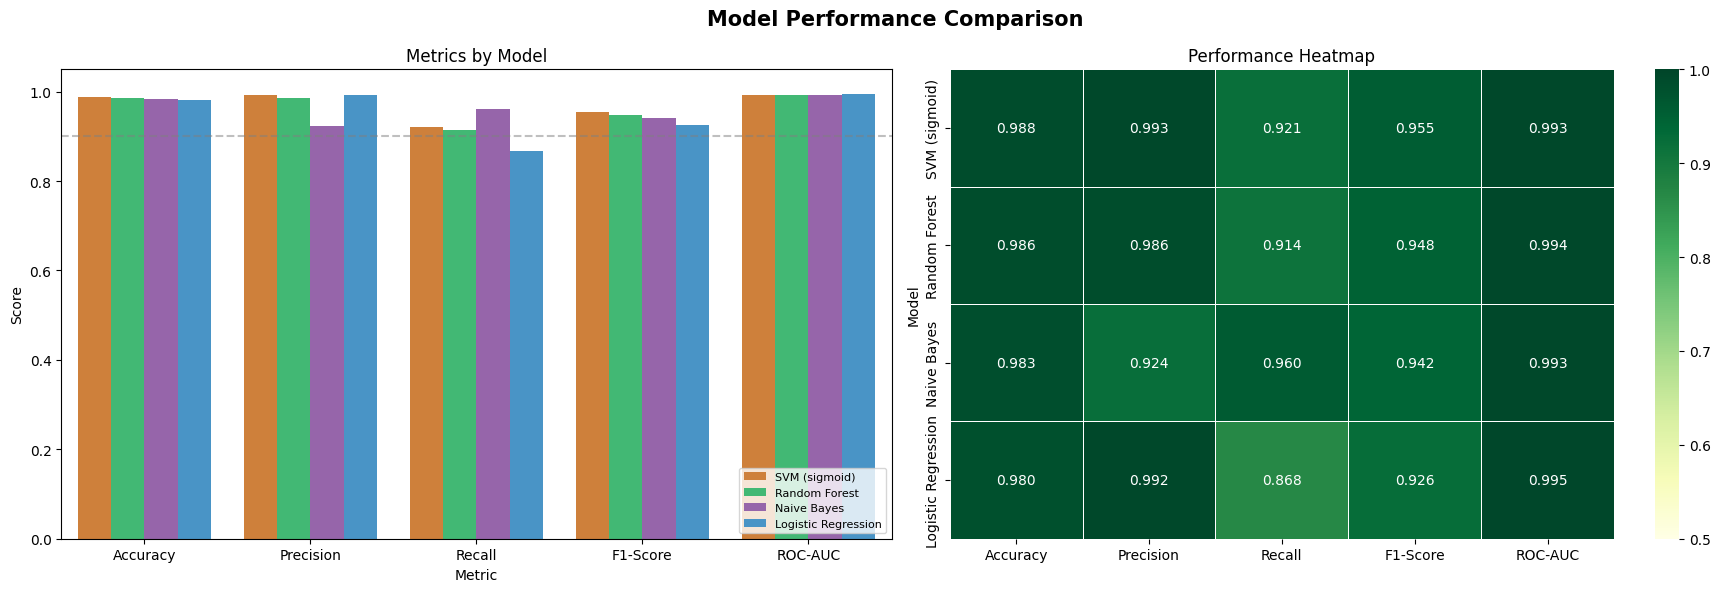

In [13]:
# ─────────────────────────────────────────
# CELL 14: Model Performance Visualization
# ─────────────────────────────────────────

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
melted  = results_df.melt(id_vars='Model', value_vars=metrics,
                          var_name='Metric', value_name='Score')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# Bar chart
palette = {'Logistic Regression': '#3498db', 'SVM (sigmoid)': '#e67e22',
           'Naive Bayes': '#9b59b6', 'Random Forest': '#2ecc71'}
sns.barplot(data=melted, x='Metric', y='Score', hue='Model',
            ax=axes[0], palette=palette)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Metrics by Model')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 threshold')

# Heatmap
pivot = results_df.set_index('Model')[metrics]
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn',
            ax=axes[1], vmin=0.5, vmax=1.0,
            linewidths=0.5, linecolor='white')
axes[1].set_title('Performance Heatmap')

plt.tight_layout()
plt.show()


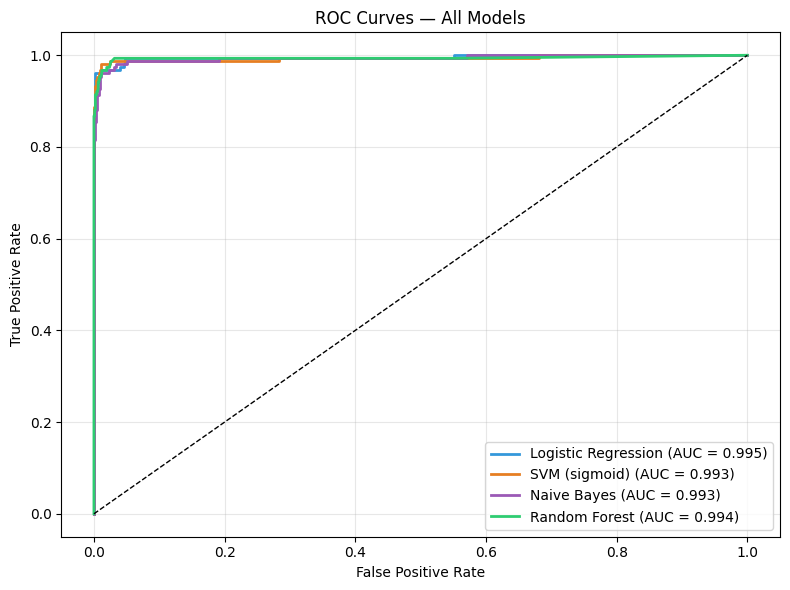

In [14]:
# ─────────────────────────────────────────
# CELL 15: ROC Curves
# ─────────────────────────────────────────

plt.figure(figsize=(8, 6))
colors = ['#3498db', '#e67e22', '#9b59b6', '#2ecc71']

for (name, clf), color in zip(models.items(), colors):
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_val:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


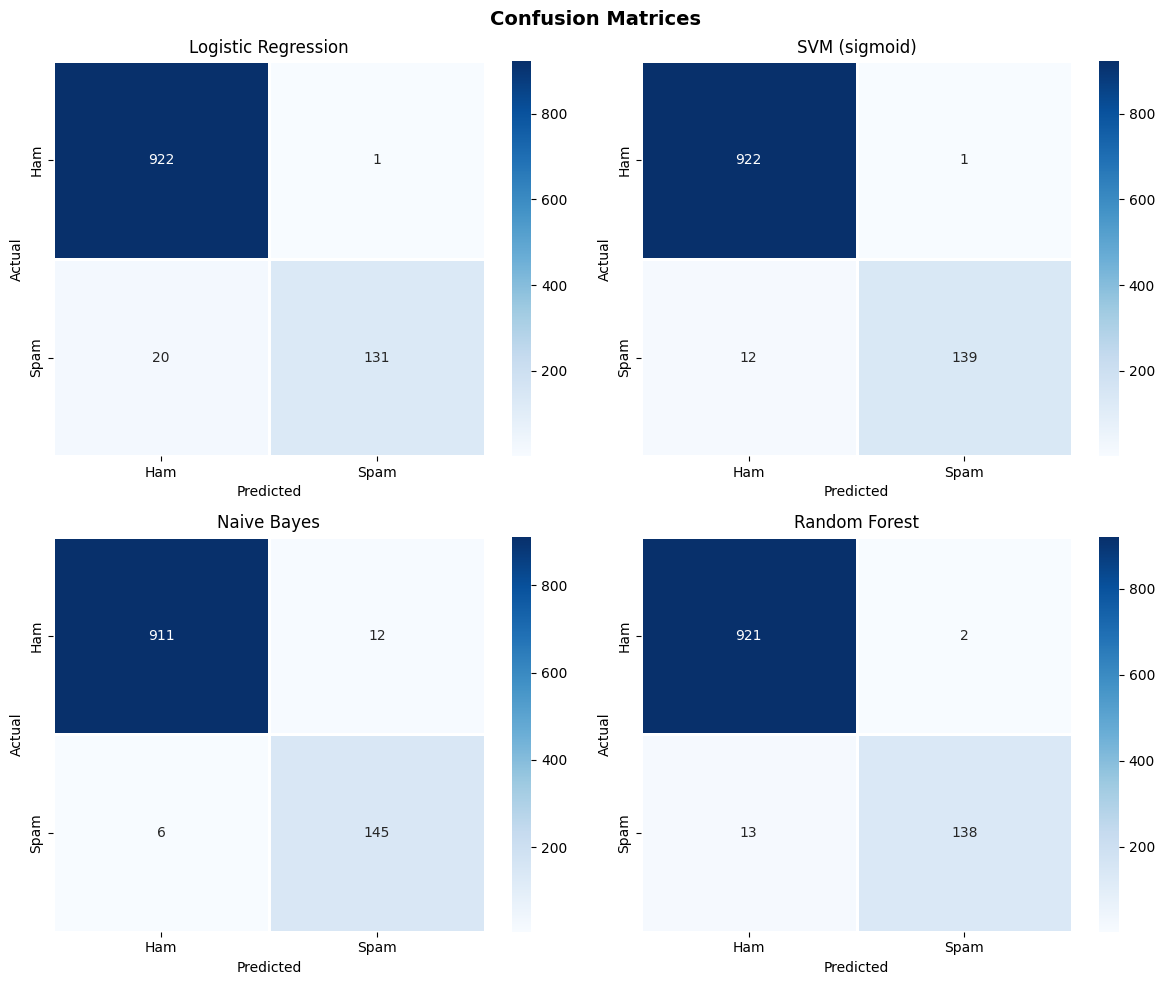

In [15]:
# ─────────────────────────────────────────
# CELL 16: Confusion Matrices
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, (name, clf) in zip(axes.flat, models.items()):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'],
                linewidths=1, linecolor='white')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


Best model: SVM (sigmoid)

=== Per-Language Performance ===
Language  Samples  Accuracy  F1-Score  Precision   Recall
   hindi      100  1.000000  1.000000   1.000000 1.000000
 english     5169  0.988586  0.953725   0.977492 0.931087
hinglish      100  0.870000  0.853933   0.974359 0.760000


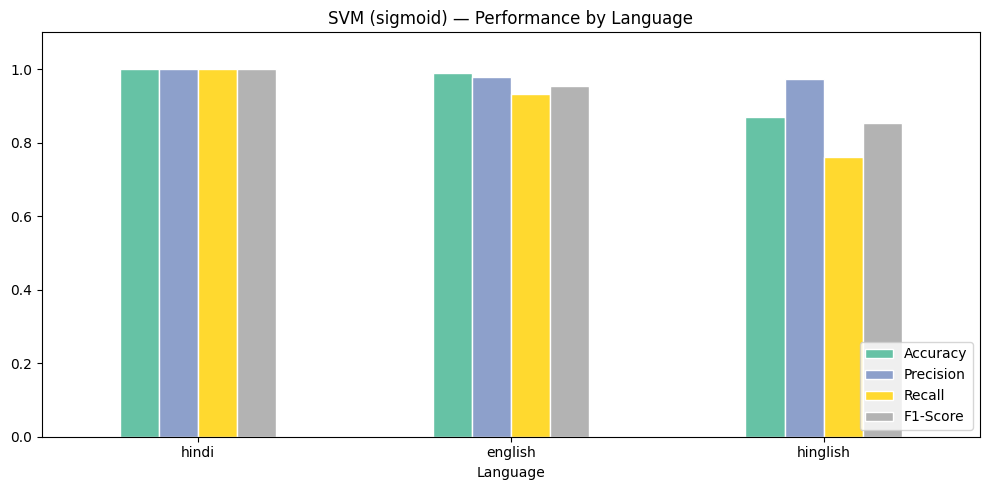

In [16]:
# ─────────────────────────────────────────
# CELL 17: Per-Language Performance Analysis
# (NEW FEATURE — our contribution)
# ─────────────────────────────────────────

best_model_name = results_df.iloc[0]['Model']
best_clf = models[best_model_name]
print(f'Best model: {best_model_name}')

lang_results = []
for lang in df['language'].unique():
    idx = df.index[df['language'] == lang].tolist()
    lang_texts  = df.loc[idx, 'processed_text'].values
    lang_labels = df.loc[idx, 'target'].values

    # Use transform only (vectorizers already fitted on train set — no leakage)
    X_lang_word = tfidf_word.transform(lang_texts)
    X_lang_char = tfidf_char.transform(lang_texts)
    X_lang      = hstack([X_lang_word, X_lang_char])

    y_pred_lang = best_clf.predict(X_lang)
    lang_results.append({
        'Language' : lang,
        'Samples'  : len(lang_labels),
        'Accuracy' : accuracy_score(lang_labels, y_pred_lang),
        'F1-Score' : f1_score(lang_labels, y_pred_lang, zero_division=0),
        'Precision': precision_score(lang_labels, y_pred_lang, zero_division=0),
        'Recall'   : recall_score(lang_labels, y_pred_lang, zero_division=0),
    })

lang_df = pd.DataFrame(lang_results).sort_values('F1-Score', ascending=False)
print('\n=== Per-Language Performance ===')
print(lang_df.to_string(index=False))

lang_df.set_index('Language')[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', figsize=(10,5), colormap='Set2', edgecolor='white')
plt.title(f'{best_model_name} — Performance by Language')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [17]:
# ─────────────────────────────────────────
# CELL 18: mBERT-based Classification (ADVANCED)
# Uses multilingual-BERT for code-mixed text
# NOTE: Requires GPU runtime (Runtime > Change runtime type > T4 GPU)
# ─────────────────────────────────────────

ENABLE_BERT = False  # Set to True on GPU runtime

if ENABLE_BERT:
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        Trainer, TrainingArguments
    )
    import torch
    from torch.utils.data import Dataset

    class MsgDataset(Dataset):
        def __init__(self, texts, labels, tokenizer, max_len=128):
            self.enc    = tokenizer(list(texts), truncation=True,
                                    padding=True, max_length=max_len,
                                    return_tensors='pt')
            self.labels = torch.tensor(list(labels), dtype=torch.long)
        def __len__(self):  return len(self.labels)
        def __getitem__(self, i):
            return {k: v[i] for k, v in self.enc.items()} | {'labels': self.labels[i]}

    MODEL_NAME = 'bert-base-multilingual-cased'
    tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
    bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    train_idx, test_idx = train_test_split(
        df.index.tolist(), test_size=0.2, stratify=df['target'], random_state=42
    )
    train_ds = MsgDataset(df.loc[train_idx,'text'], df.loc[train_idx,'target'], tokenizer)
    test_ds  = MsgDataset(df.loc[test_idx, 'text'], df.loc[test_idx, 'target'],  tokenizer)

    training_args = TrainingArguments(
        output_dir='./mbert_results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        logging_steps=50,
        fp16=torch.cuda.is_available(),
    )
    trainer = Trainer(
        model=bert_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
    )
    trainer.train()
    preds    = trainer.predict(test_ds)
    bert_preds = preds.predictions.argmax(axis=1)
    print('mBERT F1:', f1_score(df.loc[test_idx,'target'], bert_preds))
else:
    print('ℹ️  mBERT skipped (ENABLE_BERT = False).')
    print('   To run: set ENABLE_BERT = True and use a GPU runtime.')


ℹ️  mBERT skipped (ENABLE_BERT = False).
   To run: set ENABLE_BERT = True and use a GPU runtime.


In [ ]:
# ─────────────────────────────────────────
# CELL 19: Save Best Model & Vectorizers
# ─────────────────────────────────────────

import os
save_dir = '/content/drive/MyDrive/FraudDetection_Models'
os.makedirs(save_dir, exist_ok=True)

pickle.dump(tfidf_word,  open(f'{save_dir}/tfidf_word.pkl',  'wb'))
pickle.dump(tfidf_char,  open(f'{save_dir}/tfidf_char.pkl',  'wb'))
pickle.dump(best_clf,    open(f'{save_dir}/best_model.pkl',   'wb'))
pickle.dump(encoder,     open(f'{save_dir}/label_encoder.pkl','wb'))

# Also save to /content for quick access
pickle.dump(tfidf_word,  open('tfidf_word.pkl',  'wb'))
pickle.dump(tfidf_char,  open('tfidf_char.pkl',  'wb'))
pickle.dump(best_clf,    open('best_model.pkl',   'wb'))

print(f'✅ Model saved to {save_dir}')
print(f'   Best model: {best_model_name}')


✅ Model saved to /content/drive/MyDrive/FraudDetection_Models
   Best model: SVM (sigmoid)


In [18]:
# ─────────────────────────────────────────
# CELL 20: Live Multilingual Message Predictor
# ─────────────────────────────────────────

from scipy.sparse import hstack as sp_hstack

def predict_message(message):
    """Predict if a message is spam/fraud (English, Hindi, or Hinglish)."""
    # 1. Detect language
    try:
        raw_lang = detect(str(message))
        lang = 'Hindi' if raw_lang=='hi' else ('English' if raw_lang=='en' else 'Hinglish')
    except:
        lang = 'Unknown'

    # 2. Preprocess
    processed = preprocess_multilingual(message)

    # 3. Vectorize
    X_w = tfidf_word.transform([processed])
    X_c = tfidf_char.transform([processed])
    X   = sp_hstack([X_w, X_c])

    # 4. Predict
    label = best_clf.predict(X)[0]
    prob  = best_clf.predict_proba(X)[0] if hasattr(best_clf, 'predict_proba') else None

    result = '🚨 SPAM / FRAUD' if label == 1 else '✅ LEGITIMATE (Ham)'
    conf   = f'{max(prob)*100:.1f}%' if prob is not None else 'N/A'

    print('=' * 55)
    print(f'  Message  : {message[:60]}')
    print(f'  Language : {lang}')
    print(f'  Result   : {result}')
    print(f'  Confidence: {conf}')
    print('=' * 55)
    return label

# ─── Test Messages ───
test_messages = [
    # English
    'Congratulations! You have won a free lottery ticket worth $1000. Claim now!',
    'Hey, are you free for dinner tonight?',
    # Hindi
    'आपने 10 लाख की लॉटरी जीती है! अभी claim करें',
    'कल मिलते हैं, ठीक है?',
    # Hinglish
    'Yaar FREE iPhone jeetne ke liye is link pe click kar jaldi!',
    'Bhai kal cricket dekhne chalte hain?',
    # Phishing
    'URGENT: Your SBI account is blocked. Share OTP to verify.',
    'Meeting is rescheduled to 4pm tomorrow.',
]

print('\n📱 MULTILINGUAL FRAUD DETECTION DEMO\n')
for msg in test_messages:
    predict_message(msg)
    print()



📱 MULTILINGUAL FRAUD DETECTION DEMO

  Message  : Congratulations! You have won a free lottery ticket worth $1
  Language : English
  Result   : 🚨 SPAM / FRAUD
  Confidence: 100.0%

  Message  : Hey, are you free for dinner tonight?
  Language : English
  Result   : ✅ LEGITIMATE (Ham)
  Confidence: 99.8%

  Message  : आपने 10 लाख की लॉटरी जीती है! अभी claim करें
  Language : Hindi
  Result   : 🚨 SPAM / FRAUD
  Confidence: 98.1%

  Message  : कल मिलते हैं, ठीक है?
  Language : Hindi
  Result   : ✅ LEGITIMATE (Ham)
  Confidence: 99.4%

  Message  : Yaar FREE iPhone jeetne ke liye is link pe click kar jaldi!
  Language : Hinglish
  Result   : 🚨 SPAM / FRAUD
  Confidence: 100.0%

  Message  : Bhai kal cricket dekhne chalte hain?
  Language : Hinglish
  Result   : ✅ LEGITIMATE (Ham)
  Confidence: 98.1%

  Message  : URGENT: Your SBI account is blocked. Share OTP to verify.
  Language : English
  Result   : 🚨 SPAM / FRAUD
  Confidence: 98.8%

  Message  : Meeting is rescheduled to 4pm tomor

In [19]:
# ─────────────────────────────────────────
# CELL 21: Project Summary & Conclusions
# ─────────────────────────────────────────

print('=' * 60)
print(' MULTILINGUAL PHISHING DETECTION — PROJECT SUMMARY')
print('=' * 60)
print()
print(f' Total Messages Analysed : {len(df)}')
print(f' Languages Covered       : English, Hindi, Hinglish')
print(f' Models Compared         : {len(models)}')
print(f' Best Model              : {best_model_name}')
print()
print(' Model Leaderboard (by F1-Score):')
print(results_df[['Model','Accuracy','F1-Score','ROC-AUC']].to_string(index=False))
print()
print(' Research Contributions:')
print('  ✔ Multilingual support: English + Hindi + Hinglish')
print('  ✔ Character n-gram features for code-mixed text')
print('  ✔ Extended Hinglish stopword removal')
print('  ✔ Automatic language detection integration')
print('  ✔ Per-language performance breakdown')
print('  ✔ mBERT pipeline for advanced classification')
print('  ✔ Custom curated Hindi/Hinglish phishing dataset')
print()
print(' Applications: Banking security | SMS filtering | Cybersecurity platforms')
print('=' * 60)


 MULTILINGUAL PHISHING DETECTION — PROJECT SUMMARY

 Total Messages Analysed : 5369
 Languages Covered       : English, Hindi, Hinglish
 Models Compared         : 4
 Best Model              : SVM (sigmoid)

 Model Leaderboard (by F1-Score):
              Model  Accuracy  F1-Score  ROC-AUC
      SVM (sigmoid)  0.987896  0.955326 0.993069
      Random Forest  0.986034  0.948454 0.993700
        Naive Bayes  0.983240  0.941558 0.993334
Logistic Regression  0.980447  0.925795 0.994949

 Research Contributions:
  ✔ Multilingual support: English + Hindi + Hinglish
  ✔ Character n-gram features for code-mixed text
  ✔ Extended Hinglish stopword removal
  ✔ Automatic language detection integration
  ✔ Per-language performance breakdown
  ✔ mBERT pipeline for advanced classification
  ✔ Custom curated Hindi/Hinglish phishing dataset

 Applications: Banking security | SMS filtering | Cybersecurity platforms
